# Matched comparison of mammalian gene spectra

The reusable plotting functions receive a DataFrame that is **already restricted to the same species for every gene**. This notebook filters the source table to **Mammalia** and demonstrates the requested COX1-CytB comparison; change `GENES` to any 2-5 available genes to reuse the workflow.

`MutSpec` is an opportunity-adjusted, normalized 12-component spectrum weight. It is not a raw mutation rate. Mutation labels are complemented once here so all plots use heavy-strand notation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_project_root(start=Path.cwd()):
    """Find the repository from either its root or this analysis folder."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


ROOT = find_project_root()
ANALYSIS_DIR = ROOT / "3compare_t_genes"
for directory in (ROOT, ANALYSIS_DIR):
    if str(directory) not in sys.path:
        sys.path.insert(0, str(directory))

from mtdna import canonical_order

from mutation_comparison import (
    DEFAULT_GENE_LABELS,
    SBS12_ORDER,
    DEFAULT_MUTATION_RATIOS,
    calculate_mutation_ratios,
    orient_substitutions_to_heavy_strand,
    plot_matched_spectra,
    plot_mutation_comparison,
    plot_mutation_ratio_comparison,
    plot_within_species_differences,
    select_common_species,
    validate_matched_spectra,
)

CLASS_FILTER = "Mammalia"
# Any 2-5 genes present in the input; canonical_order fixes the mtDNA order.
GENES = canonical_order(("CO1", "Cytb"))
N_BOOT = 5_000
RANDOM_STATE = 20260722
DATA_PATH = ROOT / "1init_data" / "data" / "MutSpecVertebrates12.csv.gz"
DATA_DIR = ANALYSIS_DIR / "data"
FIGURES_DIR = ANALYSIS_DIR / "figures"
for directory in (DATA_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

def format_test_table(tests):
    """Keep small p-values legible without requiring pandas Styler."""
    formatted = tests.copy()
    for value_col, bound_col in (
        ("p_value", "p_value_underflow"),
        ("p_value_holm", "p_value_holm_underflow"),
    ):
        formatted[value_col] = [
            f"< {value:.2e}" if is_bound else f"{value:.3e}"
            for value, is_bound in zip(formatted[value_col], formatted[bound_col])
        ]
    return formatted

sns.set_theme(
    style="white", context="paper",
    rc={"font.family": "sans-serif", "axes.linewidth": 0.8},
)

In [2]:
spectra = pd.read_csv(DATA_PATH)
analysis_spectra = spectra.loc[spectra["Class"].eq(CLASS_FILTER)].copy()
if analysis_spectra.empty or set(analysis_spectra["Class"]) != {CLASS_FILTER}:
    raise ValueError(f"Expected a non-empty {CLASS_FILTER}-only dataset")
scope_label = CLASS_FILTER
available_genes = sorted(analysis_spectra["Gene"].unique())

matched_raw, common_species = select_common_species(analysis_spectra, GENES)
matched = orient_substitutions_to_heavy_strand(matched_raw)
matched_info = validate_matched_spectra(matched, genes=GENES)

pair_slug = "_vs_".join(GENES)
matched_cohort = (
    matched_raw[["Species", "Class"]]
    .drop_duplicates()
    .sort_values(["Class", "Species"])
)
matched_cohort.to_csv(
    DATA_DIR / f"common_species_{pair_slug}.csv", index=False
)
matched.sort_values(["Species", "Gene", "Mut"]).to_csv(
    DATA_DIR / f"matched_spectra_{pair_slug}.csv", index=False
)

class_counts = (
    matched_cohort.groupby("Class", as_index=False)
    .size()
    .rename(columns={"size": "n_common_species"})
    .sort_values("n_common_species", ascending=False)
)

def common_count(*genes):
    if not set(genes).issubset(available_genes):
        return None
    species_sets = [
        set(analysis_spectra.loc[analysis_spectra["Gene"].eq(gene), "Species"])
        for gene in genes
    ]
    return len(set.intersection(*species_sets))

candidate_pair_counts = pd.DataFrame(
    [
        {"comparison": "COX3 / ND6", "data_labels": "CO3 / ND6",
         "n_common_vertebrates": common_count("CO3", "ND6"),
         "status": "ND6 spectrum is absent", "selected": False},
        {"comparison": "COX1 / CytB", "data_labels": "CO1 / Cytb",
         "n_common_vertebrates": common_count("CO1", "Cytb"),
         "status": "Available requested comparison",
         "selected": tuple(GENES) == ("CO1", "Cytb")},
        {"comparison": "COX3 / ND2", "data_labels": "CO3 / ND2",
         "n_common_vertebrates": common_count("CO3", "ND2"),
         "status": "Diagnostic only; ND2 is not ND6", "selected": False},
    ]
)
candidate_pair_counts.to_csv(DATA_DIR / "candidate_pair_counts.csv", index=False)

display(pd.DataFrame({"available_spectrum_genes": available_genes}))
display(class_counts.reset_index(drop=True))
print(
    f"Selected: {' / '.join(DEFAULT_GENE_LABELS.get(g, g) for g in GENES)}; "
    f"N = {matched_info.n_species} common species across {scope_label}."
)
print("ND6 is absent from this spectrum file and is not replaced by ND2.")

,available_spectrum_genes
0,CO1
1,CO3
2,Cytb
3,ND2


,Class,n_common_species
0,Mammalia,104


Selected: COX1 / CytB; N = 104 common species across Mammalia.
ND6 is absent from this spectrum file and is not replaced by ND2.


## Complementary-substitution ratios

As in stage 4, `C>T/G>A` and `A>G/T>C` are calculated separately within every species/gene profile, without a pseudocount. Because the same normalization constant applies to all 12 components in a profile, these ratios are identical before and after the final spectrum normalization. Every faint line is one species, and the boxes show medians and interquartile ranges. The log axis preserves the strongly right-skewed ratio distributions. The figure annotation reports only the paired one-sided Wilcoxon test and its p-value; the pre-specified `CytB > COX1` direction remains explicit in the result table below.

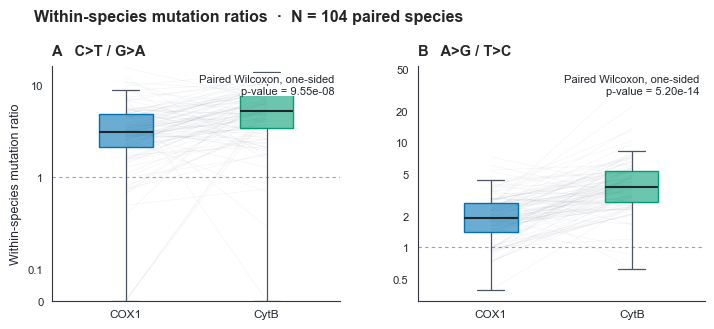

,Gene,Ratio,NumeratorMut,DenominatorMut,n_species,estimate,ci_low,ci_high,median,confidence
1,CO1,A>G/T>C,A>G,T>C,104,2.16187,1.94503,2.39648,1.92820,0.95
3,Cytb,A>G/T>C,A>G,T>C,104,4.79263,4.02886,5.78189,3.75037,0.95
0,CO1,C>T/G>A,C>T,G>A,104,3.65830,3.17871,4.18072,3.05551,0.95
2,Cytb,C>T/G>A,C>T,G>A,104,5.66659,5.07701,6.25952,5.21629,0.95


,Ratio,Gene1,Gene2,n_species,n_nonzero_pairs,statistic,p_value,p_value_underflow,median_paired_difference,difference_definition,alternative,alternative_hypothesis,scipy_alternative_on_gene1_minus_gene2,test,p_value_holm,p_value_holm_underflow
0,C>T/G>A,CO1,Cytb,104,104,1124.0,9.547e-08,False,2.418207,Gene2 - Gene1,greater,Cytb > CO1,less,Paired Wilcoxon signed-rank (one-sided),9.547e-08,False
1,A>G/T>C,CO1,Cytb,104,104,437.0,5.199e-14,False,1.852202,Gene2 - Gene1,greater,Cytb > CO1,less,Paired Wilcoxon signed-rank (one-sided),5.199e-14,False


In [3]:
ratio_values = calculate_mutation_ratios(
    matched, genes=GENES, ratios=DEFAULT_MUTATION_RATIOS,
    zero_denominator="raise",
)
ratio_values.to_csv(
    DATA_DIR / f"matched_mutation_ratios_{pair_slug}.csv", index=False
)

ratio_plot = plot_mutation_ratio_comparison(
    matched, genes=GENES, ratios=DEFAULT_MUTATION_RATIOS,
    zero_denominator="raise", n_boot=N_BOOT,
    random_state=RANDOM_STATE, pairwise_alternative="greater",
)
ratio_plot.fig.savefig(
    FIGURES_DIR / f"matched_mutation_ratios_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
ratio_plot.fig.savefig(
    FIGURES_DIR / f"matched_mutation_ratios_{pair_slug}.pdf",
    bbox_inches="tight",
)
ratio_plot.summary.to_csv(
    DATA_DIR / f"matched_mutation_ratio_summary_{pair_slug}.csv", index=False
)
ratio_plot.pairwise_tests.to_csv(
    DATA_DIR / f"matched_mutation_ratio_pairwise_tests_{pair_slug}.csv",
    index=False,
)
plt.show()
plt.close(ratio_plot.fig)
display(ratio_plot.summary.sort_values(["Ratio", "Gene"]).round(5))
display(format_test_table(ratio_plot.pairwise_tests))

## Complete 12-component comparison

Points are means and whiskers are 95% cluster-bootstrap intervals obtained by resampling matched species. Categories are not connected because the 12 substitutions have no continuous x-axis.

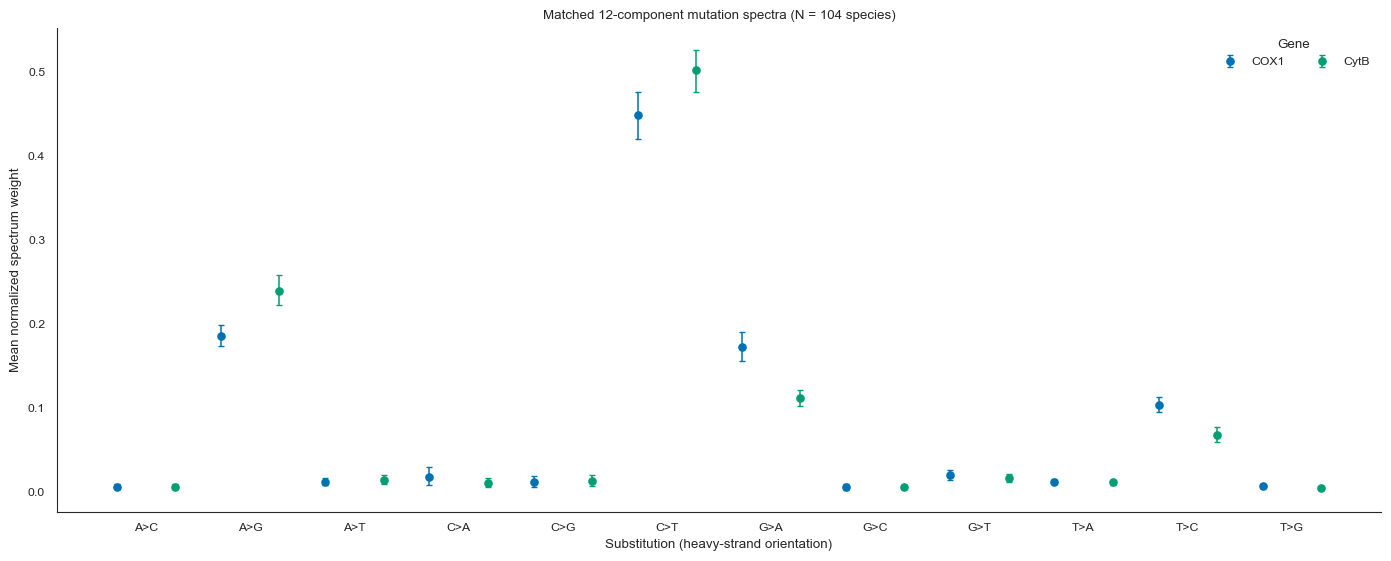

Gene,CO1,Cytb
Mut,,
A>C,0.0057,0.0054
A>G,0.1860,0.2393
A>T,0.0117,0.0142
C>A,0.0178,0.0104
C>G,0.0111,0.0128
C>T,0.4483,0.5030
G>A,0.1723,0.1118
G>C,0.0057,0.0049
G>T,0.0195,0.0156


In [4]:
spectrum_plot = plot_matched_spectra(
    matched, genes=GENES, n_boot=N_BOOT, random_state=RANDOM_STATE
)
spectrum_plot.fig.savefig(
    FIGURES_DIR / f"matched_12_component_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
spectrum_plot.summary.to_csv(
    DATA_DIR / f"matched_12_component_summary_{pair_slug}.csv", index=False
)
plt.show()
plt.close(spectrum_plot.fig)

display(
    spectrum_plot.summary.pivot(
        index="Mut", columns="Gene", values="estimate"
    ).loc[list(spectrum_plot.summary["Mut"].drop_duplicates())].round(4)
)

## Within-species differences without the 100% normalization

The figures above use `MutSpec`, where the 12 components of every species/gene
profile sum to one. That closure makes the components dependent: if `C>T` rises
in CytB, something else must fall even when nothing about it changed.

This figure differences the pre-normalization quantity instead:

```text
OpportunityAdjusted = Observed.fillna(0) / Expected
```

It is an opportunity-adjusted reconstructed substitution burden, not an
absolute mutation frequency or per-generation rate. Every species still
contributes one paired difference `CytB - COX1` per substitution, so the
comparison stays matched; only the normalization is gone.

Two panels show the same numbers: the first on the full range, the second
scaled to the smaller components, with `C>T` and `A>G` omitted there because
they run far off that scale.

In [ ]:
# Remove the 100% normalization and difference Observed / Expected instead.
expected = pd.to_numeric(matched["Expected"], errors="raise")
observed = pd.to_numeric(matched["Observed"], errors="raise").fillna(0)
if (not np.isfinite(expected).all()) or expected.le(0).any():
    raise ValueError("Expected opportunities must be finite and strictly positive")
if (not np.isfinite(observed).all()) or observed.lt(0).any():
    raise ValueError("Observed reconstructed burdens must be finite and non-negative")

matched_opportunity_adjusted = matched.copy()
matched_opportunity_adjusted["OpportunityAdjusted"] = observed / expected

# C>T and A>G dominate the unnormalized range; the zoom panel keeps the rest readable.
SMALL_COMPONENTS = tuple(
    mutation for mutation in SBS12_ORDER if mutation not in ("C>T", "A>G")
)
contrast_label = " - ".join(
    DEFAULT_GENE_LABELS.get(gene, gene) for gene in (GENES[-1], GENES[0])
)

difference_plot = plot_within_species_differences(
    matched_opportunity_adjusted,
    genes=GENES,
    value_col="OpportunityAdjusted",
    require_sum_to_one=False,
    zoom_mutations=SMALL_COMPONENTS,
    y_label=f"Paired difference in opportunity-adjusted burden\n({contrast_label})",
    n_boot=N_BOOT,
    random_state=RANDOM_STATE,
)
difference_plot.fig.savefig(
    FIGURES_DIR / f"matched_opportunity_adjusted_differences_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
difference_plot.fig.savefig(
    FIGURES_DIR / f"matched_opportunity_adjusted_differences_{pair_slug}.pdf",
    bbox_inches="tight",
)
difference_plot.summary.to_csv(
    DATA_DIR / f"matched_opportunity_adjusted_difference_summary_{pair_slug}.csv",
    index=False,
)
difference_plot.pairwise_tests.to_csv(
    DATA_DIR / f"matched_opportunity_adjusted_difference_tests_{pair_slug}.csv",
    index=False,
)
plt.show()
plt.close(difference_plot.fig)
display(
    difference_plot.summary[[
        "Mut", "mean_difference", "ci_low", "ci_high",
        "median_difference", "fraction_species_positive",
    ]].round(4)
)

## Focus on heavy-strand C>T

Every faint line retains one within-species comparison. Boxes show medians and interquartile ranges. The figure annotation reports only the paired one-sided Wilcoxon test and its p-value; the pre-specified `CytB > COX1` direction remains explicit in the result table below.

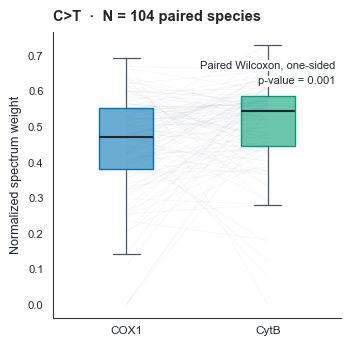

,Gene,Mut,n_species,estimate,ci_low,ci_high,estimator,confidence
5,CO1,C>T,104,0.44828,0.42019,0.47583,mean,0.95
17,Cytb,C>T,104,0.50304,0.47669,0.52690,mean,0.95


,Mut,Gene1,Gene2,n_species,n_nonzero_pairs,statistic,p_value,p_value_underflow,median_paired_difference,difference_definition,alternative,alternative_hypothesis,scipy_alternative_on_gene1_minus_gene2,test,p_value_holm,p_value_holm_underflow
0,C>T,CO1,Cytb,104,104,1795.0,1.215e-03,False,0.043669,Gene2 - Gene1,greater,Cytb > CO1,less,Paired Wilcoxon signed-rank (one-sided),1.215e-03,False


In [5]:
ct_plot = plot_mutation_comparison(
    matched, "C>T", genes=GENES, n_boot=N_BOOT,
    random_state=RANDOM_STATE, pairwise_alternative="greater",
)
ct_plot.fig.savefig(
    FIGURES_DIR / f"matched_CT_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
ct_plot.fig.savefig(
    FIGURES_DIR / f"matched_CT_{pair_slug}.pdf",
    bbox_inches="tight",
)
ct_plot.pairwise_tests.to_csv(
    DATA_DIR / f"matched_CT_pairwise_tests_{pair_slug}.csv", index=False
)
plt.show()
plt.close(ct_plot.fig)
display(ct_plot.summary.round(5))
display(format_test_table(ct_plot.pairwise_tests))

## Focus on heavy-strand G>A

The same paired display is used for `G>A`. Here the directional hypothesis is reversed (`CytB < COX1`), so `pairwise_alternative="less"` is defined as Gene2 lower than Gene1. The plot keeps only the two-line test/p-value annotation, while the direction remains in the result table.

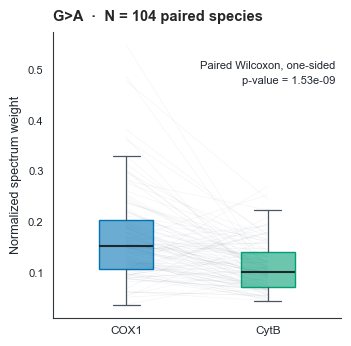

,Gene,Mut,n_species,estimate,ci_low,ci_high,estimator,confidence
6,CO1,G>A,104,0.17229,0.15528,0.18986,mean,0.95
18,Cytb,G>A,104,0.11177,0.10248,0.12124,mean,0.95


,Mut,Gene1,Gene2,n_species,n_nonzero_pairs,statistic,p_value,p_value_underflow,median_paired_difference,difference_definition,alternative,alternative_hypothesis,scipy_alternative_on_gene1_minus_gene2,test,p_value_holm,p_value_holm_underflow
0,G>A,CO1,Cytb,104,104,4558.0,1.535e-09,False,-0.057383,Gene2 - Gene1,less,Cytb < CO1,greater,Paired Wilcoxon signed-rank (one-sided),1.535e-09,False


In [6]:
ga_plot = plot_mutation_comparison(
    matched, "G>A", genes=GENES, n_boot=N_BOOT,
    random_state=RANDOM_STATE, pairwise_alternative="less",
)
ga_plot.fig.savefig(
    FIGURES_DIR / f"matched_GA_{pair_slug}.png",
    dpi=300, bbox_inches="tight",
)
ga_plot.fig.savefig(
    FIGURES_DIR / f"matched_GA_{pair_slug}.pdf",
    bbox_inches="tight",
)
ga_plot.pairwise_tests.to_csv(
    DATA_DIR / f"matched_GA_pairwise_tests_{pair_slug}.csv", index=False
)
plt.show()
plt.close(ga_plot.fig)
display(ga_plot.summary.round(5))
display(format_test_table(ga_plot.pairwise_tests))

The comparison is descriptive: species are paired but phylogenetically non-independent, and the 12 normalized components are compositional. The one-sided directions were specified from the biological hypothesis before testing; they were not selected after inspecting the effect. Publication-level inference should therefore use a phylogeny-aware compositional model rather than treating species as independent evolutionary replicates.